In [1]:
import os
from dotenv import load_dotenv
import xarray as xr

import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

import analysis_utils
import isku_utils

import importlib

importlib.reload(analysis_utils)
importlib.reload(isku_utils)

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'isku_utils' from '/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py'>

In [2]:
load_dotenv()
DATA_DIR = os.environ["DATA_DIR"]
IMPACT_REGION_POLYGONS = os.environ["POREALLAS_REGIONS_POLYGONS_URI"]
SOCIOECONOMICS_URI = os.environ["POREALLAS_SOCIOECONOMICS_URI"]

In [3]:
# Impact Regions
_polygons = (
    gpd.read_parquet(os.path.join(DATA_DIR, IMPACT_REGION_POLYGONS))
    .rename(columns={"hierid": "region"})
    .set_index("region")
    .set_crs(epsg=4326)  # Assuming the data is WGS-82.
)

# Socioeconomics
socioeconomics = xr.open_zarr(os.path.join(DATA_DIR, SOCIOECONOMICS_URI))
socioeconomics = socioeconomics.sel(year=2026)[
    ["pop", "gdppc", "iso3"]
]

In [4]:
# Define Forecast Months
fc_months = [8, 9, 10, 11, 12, 1]

In [5]:
def compute_area_weighted_mean(ds, lat_name="lat", lon_name="lon"):
    weights = np.cos(np.deg2rad(ds[lat_name]))
    weights.name = "weights"
    return ds.weighted(weights).mean((lat_name, lon_name))

In [6]:
POREALLAS_PARSED_ERA5_URI = "gs://poreallas-public-20260605/v20260731/parsed/era5.zarr"
ERA5_RECENT = "/home/emily_zuetell/projects/poreallas/data/parsed/26_era5_daily_running.zarr"
POREALLAS_PARSED_FORECAST_URI = "/home/emily_zuetell/projects/poreallas/data/parsed/08_ecmwf_parsed.zarr"

In [7]:
era5 = xr.load_dataset(
        POREALLAS_PARSED_ERA5_URI,
        engine="zarr",
        backend_kwargs={"storage_options": {"token": "anon"}},
    )
era5_recent = xr.open_zarr(ERA5_RECENT).rename({'t2m': 'tas'})
era5_full = xr.merge([era5, era5_recent]) # Original data to 2025, add on recent 2026 ERA5 data

/tmp/ipykernel_22811/1573885855.py:7: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  era5_full = xr.merge([era5, era5_recent]) # Original data to 2025, add on recent 2026 ERA5 data
/tmp/ipykernel_22811/1573885855.py:7: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  era5_full = xr.merge([era5, era5_recent]) # Original data to 2025, add on recent 202

In [8]:
forecast = xr.open_zarr(
        POREALLAS_PARSED_FORECAST_URI)

In [9]:
# Analysis Period (1995-2027)
era5_analysis = era5.sel(time=slice("1995-01-01", "2014-12-31"))
era5_analysis = era5_analysis.sel(time=era5_analysis.time.dt.month.isin([fc_months])).compute()
forecast_analysis = forecast.sel(time=slice("2026-08-01", "2027-01-31")).compute()

In [14]:
era5_analysis

<xarray.Dataset> Size: 954MB
Dimensions:    (time: 3680, latitude: 180, longitude: 360)
Coordinates:
  * time       (time) object 29kB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
  * latitude   (latitude) float64 1kB 89.5 88.5 87.5 86.5 ... -87.5 -88.5 -89.5
  * longitude  (longitude) float64 3kB 0.5 1.5 2.5 3.5 ... 357.5 358.5 359.5
Data variables:
    tas        (time, latitude, longitude) float32 954MB 239.8 239.8 ... 246.0
Attributes:
    regrid_method:          bilinear
    last_updated:           2026-07-30 03:04:12.745631+00:00
    valid_time_start:       1940-01-01
    valid_time_stop:        2026-04-30
    valid_time_stop_era5t:  2026-07-24
    poreallas_created_at:   2026-07-31T23:27:06.816984+00:00
    poreallas_uid:          3ef1dbad-c796-48b7-8b07-99616d3853d1
    poreallas_description:  Parsed ERA5 climate fields

In [15]:
forecast_analysis

<xarray.Dataset> Size: 2GB
Dimensions:                  (number: 51, latitude: 180, longitude: 360,
                              time: 183)
Coordinates:
  * number                   (number) int64 408B 0 1 2 3 4 5 ... 46 47 48 49 50
  * latitude                 (latitude) float64 1kB 89.5 88.5 ... -88.5 -89.5
  * longitude                (longitude) float64 3kB 0.5 1.5 2.5 ... 358.5 359.5
  * time                     (time) object 1kB 2026-08-02 00:00:00 ... 2027-0...
    forecast_period          (time) timedelta64[ns] 1kB 1 days ... 183 days
    forecast_reference_time  (time) datetime64[ns] 1kB 2026-08-01 ... 2026-08-01
Data variables:
    tas                      (number, latitude, longitude, time) float32 2GB ...
Attributes:
    poreallas_created_at:   2026-08-06T16:07:16.417760+00:00
    poreallas_uid:          5fa02d07-3f21-4c51-81e1-eef50b730e39
    poreallas_description:  Parsed ECMWF S51 ensemble fields

In [16]:
era5_hot_days_per_year = ((era5_analysis['tas']-273.15) > 32).groupby("time.year").sum(dim="time")
forecast_hot_days_per_year = ((forecast_analysis['tas']-273.15) > 32).groupby("time.year").sum(dim="time")

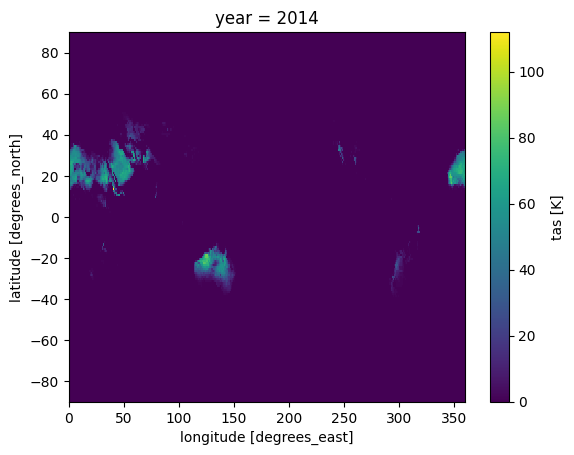

In [19]:
era5_hot_days_per_year.sel(year = 2014).plot()

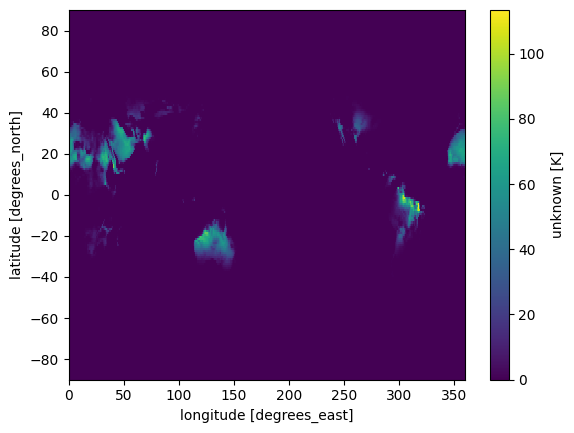

In [18]:
forecast_hot_days_per_year.sum(dim = 'year').mean(dim = 'number').plot()

In [11]:
fc_land = compute_area_weighted_mean(analysis_utils.land_only(forecast_hot_days_per_year))
era5_land = compute_area_weighted_mean(analysis_utils.land_only(era5_hot_days_per_year))

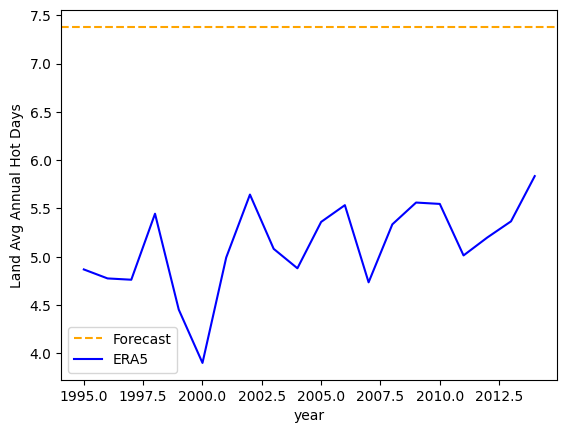

In [29]:
plt.axhline(fc_land.sum(dim='year').mean(dim='number').values, color='orange', linestyle='--', label='Forecast')
era5_land.plot(label='ERA5', color='blue')
plt.ylabel('Land Avg Annual Hot Days')
plt.legend()

In [34]:
# For Context: Full ERA5 Data
era5_ALL = era5.sel(time=era5.time.dt.month.isin([fc_months])).compute()
era5_hot_days_per_year_ALL = ((era5_ALL['tas']-273.15) > 32).groupby("time.year").sum(dim="time")
era5_land_ALL = compute_area_weighted_mean(analysis_utils.land_only(era5_hot_days_per_year_ALL))

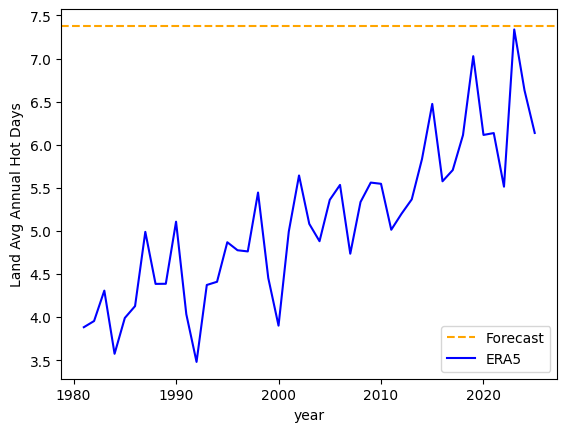

In [35]:
plt.axhline(fc_land.sum(dim='year').mean(dim='number').values, color='orange', linestyle='--', label='Forecast')
era5_land_ALL.plot(label='ERA5', color='blue')
plt.ylabel('Land Avg Annual Hot Days')
plt.legend()

In [12]:
MEAN = (fc_land.sum(dim = 'year')/era5_land.mean(dim = 'year')).mean(dim = 'number')
SE = ((fc_land.sum(dim = 'year')/era5_land.mean(dim = 'year')).std(dim = 'number'))/np.sqrt(fc_land.sum(dim = 'year').shape[0])

In [13]:
print(f"Mean: {MEAN.values:.2f}, SE: {SE.values:.3f}")

Mean: 1.44, SE: 0.013
